In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [22]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
Unnamed: 0
Clothing ID
Age
Title
Review Text
Rating
Recommended IND
Positive Feedback Count
Division Name
Department Name
Class Name


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [24]:
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")

print("Updated dataset shape:", df.shape)
print("Remaining columns:")
print(df.columns.tolist())

Updated dataset shape: (23486, 10)
Remaining columns:
['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [25]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Clothing ID', 'Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']


In [26]:
continuous_outlier_columns = [
    "Age",
    "Positive Feedback Count"
]

identifier_columns = [
    "Clothing ID"
]

fixed_range_columns = [
    "Rating"
]

binary_columns = [
    "Recommended IND"
]

print("Outlier detection columns:", continuous_outlier_columns)
print("Identifier columns:", identifier_columns)
print("Fixed-range columns:", fixed_range_columns)
print("Binary columns:", binary_columns)

Outlier detection columns: ['Age', 'Positive Feedback Count']
Identifier columns: ['Clothing ID']
Fixed-range columns: ['Rating']
Binary columns: ['Recommended IND']


In [27]:
print(
    df[continuous_outlier_columns]
    .isnull()
    .sum()
)

Age                        0
Positive Feedback Count    0
dtype: int64


In [28]:
selected_columns = [
    "Age",
    "Positive Feedback Count",
    "Rating",
    "Recommended IND"
]

df[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0


In [29]:
validation_results = {
    "Invalid Age": (
        (df["Age"] < 13) |
        (df["Age"] > 100)
    ).sum(),

    "Negative Feedback Count": (
        df["Positive Feedback Count"] < 0
    ).sum(),

    "Invalid Rating": (
        ~df["Rating"].between(1, 5)
    ).sum(),

    "Invalid Recommended IND": (
        ~df["Recommended IND"].isin([0, 1])
    ).sum()
}

for condition, count in validation_results.items():
    print(f"{condition}: {count}")

Invalid Age: 0
Negative Feedback Count: 0
Invalid Rating: 0
Invalid Recommended IND: 0


In [30]:
print("Highest ages:")
display(
    df.nlargest(10, "Age")[
        ["Age", "Rating", "Positive Feedback Count"]
    ]
)

print("Highest positive feedback counts:")
display(
    df.nlargest(10, "Positive Feedback Count")[
        [
            "Age",
            "Rating",
            "Positive Feedback Count",
            "Department Name",
            "Class Name"
        ]
    ]
)

Highest ages:


,Age,Rating,Positive Feedback Count
8327,99,5,1
11545,99,4,4
6543,94,4,0
18036,94,1,0
18563,94,5,1
659,93,5,3
17578,93,4,0
14997,92,5,2
9513,91,5,15
10617,91,2,3


Highest positive feedback counts:


,Age,Rating,Positive Feedback Count,Department Name,Class Name
7218,34,3,122,Dresses,Dresses
1294,29,5,117,Dresses,Dresses
7765,43,1,108,Jackets,Jackets
19094,35,5,99,Jackets,Outerwear
13210,23,5,98,Dresses,Dresses
16329,56,4,95,Tops,Knits
2123,39,5,94,Dresses,Dresses
17233,23,4,93,Tops,Knits
9427,37,5,89,Dresses,Dresses
8683,52,4,87,Dresses,Dresses


In [31]:
sns.set_theme(style="whitegrid")

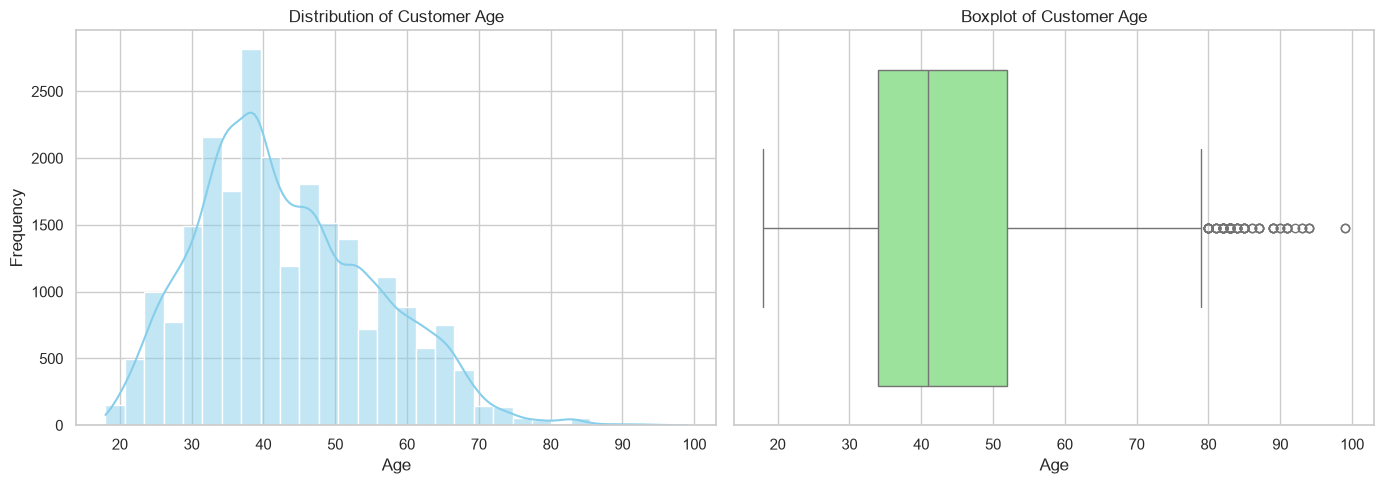

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True,
    ax=axes[0],
    color="skyblue"
)
axes[0].set_title("Distribution of Customer Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    data=df,
    x="Age",
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title("Boxplot of Customer Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

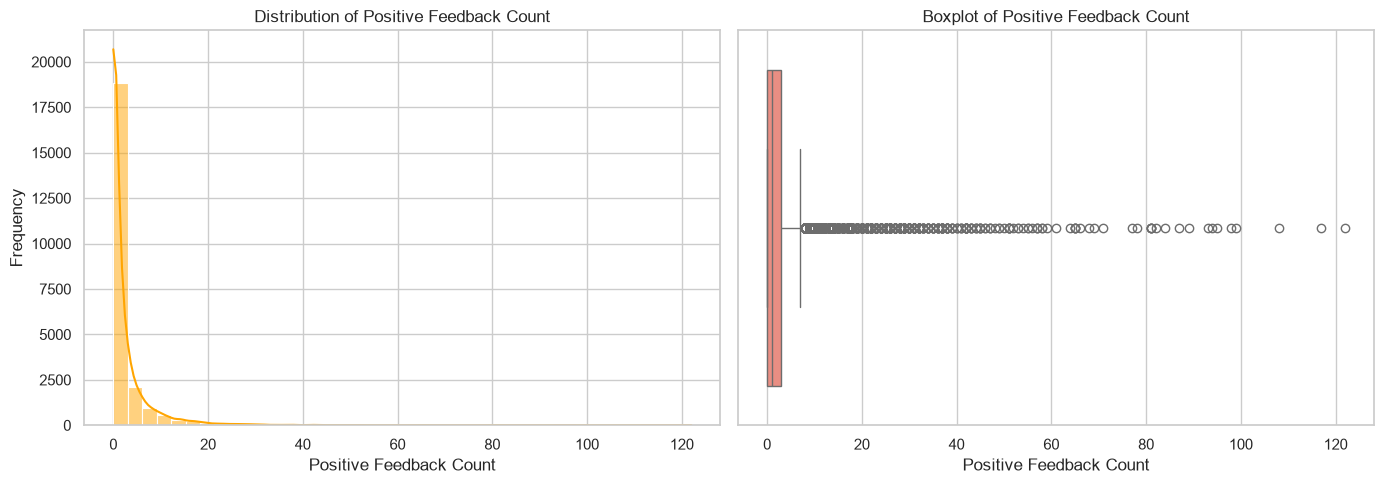

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="Positive Feedback Count",
    bins=40,
    kde=True,
    ax=axes[0],
    color="orange"
)
axes[0].set_title("Distribution of Positive Feedback Count")
axes[0].set_xlabel("Positive Feedback Count")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    data=df,
    x="Positive Feedback Count",
    ax=axes[1],
    color="salmon"
)
axes[1].set_title("Boxplot of Positive Feedback Count")
axes[1].set_xlabel("Positive Feedback Count")

plt.tight_layout()
plt.show()

In [34]:
for column in continuous_outlier_columns:
    skewness = df[column].skew()
    print(f"{column} skewness: {skewness:.2f}")

Age skewness: 0.53
Positive Feedback Count skewness: 6.47


In [35]:
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outlier_mask = (
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    )

    outliers = data.loc[outlier_mask].copy()

    return {
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "outlier_count": outlier_mask.sum(),
        "outlier_percentage": outlier_mask.mean() * 100,
        "mask": outlier_mask,
        "outliers": outliers
    }

In [36]:
age_iqr = detect_outliers_iqr(df, "Age")

print("Column:", age_iqr["column"])
print("Q1:", age_iqr["q1"])
print("Q3:", age_iqr["q3"])
print("IQR:", age_iqr["iqr"])
print("Lower limit:", age_iqr["lower_limit"])
print("Upper limit:", age_iqr["upper_limit"])
print("Outlier count:", age_iqr["outlier_count"])
print(
    "Outlier percentage:",
    round(age_iqr["outlier_percentage"], 2),
    "%"
)

Column: Age
Q1: 34.0
Q3: 52.0
IQR: 18.0
Lower limit: 7.0
Upper limit: 79.0
Outlier count: 109
Outlier percentage: 0.46 %


In [37]:
display(
    age_iqr["outliers"][
        [
            "Age",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count",
            "Department Name",
            "Class Name"
        ]
    ].sort_values("Age", ascending=False).head(15)
)

,Age,Rating,Recommended IND,Positive Feedback Count,Department Name,Class Name
8327,99,5,1,1,Dresses,Dresses
11545,99,4,1,4,Tops,Sweaters
6543,94,4,1,0,Dresses,Dresses
18563,94,5,1,1,Dresses,Dresses
18036,94,1,0,0,Dresses,Dresses
17578,93,4,1,0,Tops,Fine gauge
659,93,5,1,3,Intimate,Swim
14997,92,5,1,2,Bottoms,Jeans
15802,91,3,0,0,Bottoms,Jeans
9513,91,5,1,15,Tops,Knits


In [38]:
print(
    "Minimum outlier age:",
    age_iqr["outliers"]["Age"].min()
)

print(
    "Maximum outlier age:",
    age_iqr["outliers"]["Age"].max()
)

Minimum outlier age: 80
Maximum outlier age: 99


In [39]:
feedback_iqr = detect_outliers_iqr(
    df,
    "Positive Feedback Count"
)

print("Column:", feedback_iqr["column"])
print("Q1:", feedback_iqr["q1"])
print("Q3:", feedback_iqr["q3"])
print("IQR:", feedback_iqr["iqr"])
print("Lower limit:", feedback_iqr["lower_limit"])
print("Upper limit:", feedback_iqr["upper_limit"])
print("Outlier count:", feedback_iqr["outlier_count"])
print(
    "Outlier percentage:",
    round(feedback_iqr["outlier_percentage"], 2),
    "%"
)

Column: Positive Feedback Count
Q1: 0.0
Q3: 3.0
IQR: 3.0
Lower limit: -4.5
Upper limit: 7.5
Outlier count: 2147
Outlier percentage: 9.14 %


In [40]:
display(
    feedback_iqr["outliers"][
        [
            "Age",
            "Rating",
            "Positive Feedback Count",
            "Department Name",
            "Class Name"
        ]
    ]
    .sort_values(
        "Positive Feedback Count",
        ascending=False
    )
    .head(15)
)

,Age,Rating,Positive Feedback Count,Department Name,Class Name
7218,34,3,122,Dresses,Dresses
1294,29,5,117,Dresses,Dresses
7765,43,1,108,Jackets,Jackets
19094,35,5,99,Jackets,Outerwear
13210,23,5,98,Dresses,Dresses
16329,56,4,95,Tops,Knits
2123,39,5,94,Dresses,Dresses
17233,23,4,93,Tops,Knits
9427,37,5,89,Dresses,Dresses
8683,52,4,87,Dresses,Dresses


In [41]:
print(
    "Minimum feedback outlier:",
    feedback_iqr["outliers"][
        "Positive Feedback Count"
    ].min()
)

print(
    "Maximum feedback outlier:",
    feedback_iqr["outliers"][
        "Positive Feedback Count"
    ].max()
)

Minimum feedback outlier: 8
Maximum feedback outlier: 122


In [42]:
iqr_summary = pd.DataFrame([
    {
        "Column": "Age",
        "Q1": age_iqr["q1"],
        "Q3": age_iqr["q3"],
        "IQR": age_iqr["iqr"],
        "Lower Limit": age_iqr["lower_limit"],
        "Upper Limit": age_iqr["upper_limit"],
        "Outlier Count": age_iqr["outlier_count"],
        "Outlier Percentage":
            age_iqr["outlier_percentage"]
    },
    {
        "Column": "Positive Feedback Count",
        "Q1": feedback_iqr["q1"],
        "Q3": feedback_iqr["q3"],
        "IQR": feedback_iqr["iqr"],
        "Lower Limit": feedback_iqr["lower_limit"],
        "Upper Limit": feedback_iqr["upper_limit"],
        "Outlier Count": feedback_iqr["outlier_count"],
        "Outlier Percentage":
            feedback_iqr["outlier_percentage"]
    }
])

iqr_summary.round(2)

,Column,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count,Outlier Percentage
0,Age,34.0,52.0,18.0,7.0,79.0,109,0.46
1,Positive Feedback Count,0.0,3.0,3.0,-4.5,7.5,2147,9.14


In [43]:
def detect_outliers_zscore(data, column, threshold=3):
    valid_data = data[column].dropna()

    z_scores = pd.Series(
        zscore(valid_data),
        index=valid_data.index
    )

    outlier_mask = z_scores.abs() > threshold
    outlier_indices = z_scores[outlier_mask].index
    outliers = data.loc[outlier_indices].copy()

    return {
        "column": column,
        "threshold": threshold,
        "z_scores": z_scores,
        "outlier_indices": outlier_indices,
        "outliers": outliers,
        "outlier_count": len(outliers),
        "outlier_percentage":
            (len(outliers) / len(valid_data)) * 100
    }

In [44]:
age_zscore = detect_outliers_zscore(
    df,
    "Age",
    threshold=3
)

print("Column:", age_zscore["column"])
print("Threshold:", age_zscore["threshold"])
print("Outlier count:", age_zscore["outlier_count"])
print(
    "Outlier percentage:",
    round(age_zscore["outlier_percentage"], 2),
    "%"
)

Column: Age
Threshold: 3
Outlier count: 99
Outlier percentage: 0.42 %


In [45]:
print(
    "Minimum Z-score outlier age:",
    age_zscore["outliers"]["Age"].min()
)

print(
    "Maximum Z-score outlier age:",
    age_zscore["outliers"]["Age"].max()
)

Minimum Z-score outlier age: 81
Maximum Z-score outlier age: 99


In [46]:
age_zscore_output = age_zscore["outliers"].copy()

age_zscore_output["Age Z-score"] = (
    age_zscore["z_scores"]
    .loc[age_zscore_output.index]
)

display(
    age_zscore_output[
        [
            "Age",
            "Age Z-score",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count"
        ]
    ]
    .sort_values("Age", ascending=False)
    .head(15)
)

,Age,Age Z-score,Rating,Recommended IND,Positive Feedback Count
8327,99,4.544358,5,1,1
11545,99,4.544358,4,1,4
6543,94,4.137168,4,1,0
18563,94,4.137168,5,1,1
18036,94,4.137168,1,0,0
17578,93,4.055730,4,1,0
659,93,4.055730,5,1,3
14997,92,3.974292,5,1,2
10617,91,3.892854,2,0,3
15802,91,3.892854,3,0,0


In [47]:
feedback_zscore = detect_outliers_zscore(
    df,
    "Positive Feedback Count",
    threshold=3
)

print("Column:", feedback_zscore["column"])
print("Threshold:", feedback_zscore["threshold"])
print("Outlier count:", feedback_zscore["outlier_count"])
print(
    "Outlier percentage:",
    round(feedback_zscore["outlier_percentage"], 2),
    "%"
)

Column: Positive Feedback Count
Threshold: 3
Outlier count: 430
Outlier percentage: 1.83 %


In [48]:
print(
    "Minimum Z-score feedback outlier:",
    feedback_zscore["outliers"][
        "Positive Feedback Count"
    ].min()
)

print(
    "Maximum Z-score feedback outlier:",
    feedback_zscore["outliers"][
        "Positive Feedback Count"
    ].max()
)

Minimum Z-score feedback outlier: 20
Maximum Z-score feedback outlier: 122


In [49]:
feedback_zscore_output = feedback_zscore["outliers"].copy()

feedback_zscore_output["Feedback Z-score"] = (
    feedback_zscore["z_scores"]
    .loc[feedback_zscore_output.index]
)

display(
    feedback_zscore_output[
        [
            "Age",
            "Rating",
            "Positive Feedback Count",
            "Feedback Z-score",
            "Department Name",
            "Class Name"
        ]
    ]
    .sort_values(
        "Positive Feedback Count",
        ascending=False
    )
    .head(15)
)

,Age,Rating,Positive Feedback Count,Feedback Z-score,Department Name,Class Name
7218,34,3,122,20.950962,Dresses,Dresses
1294,29,5,117,20.074089,Dresses,Dresses
7765,43,1,108,18.495718,Jackets,Jackets
19094,35,5,99,16.917346,Jackets,Outerwear
13210,23,5,98,16.741972,Dresses,Dresses
16329,56,4,95,16.215848,Tops,Knits
2123,39,5,94,16.040473,Dresses,Dresses
17233,23,4,93,15.865099,Tops,Knits
9427,37,5,89,15.163600,Dresses,Dresses
8683,52,4,87,14.812851,Dresses,Dresses


In [50]:
detection_comparison = pd.DataFrame({
    "Column": [
        "Age",
        "Positive Feedback Count"
    ],
    "IQR Outliers": [
        age_iqr["outlier_count"],
        feedback_iqr["outlier_count"]
    ],
    "Z-score Outliers": [
        age_zscore["outlier_count"],
        feedback_zscore["outlier_count"]
    ],
    "IQR Percentage": [
        age_iqr["outlier_percentage"],
        feedback_iqr["outlier_percentage"]
    ],
    "Z-score Percentage": [
        age_zscore["outlier_percentage"],
        feedback_zscore["outlier_percentage"]
    ]
})

detection_comparison.round(2)

,Column,IQR Outliers,Z-score Outliers,IQR Percentage,Z-score Percentage
0,Age,109,99,0.46,0.42
1,Positive Feedback Count,2147,430,9.14,1.83


In [51]:
dbscan_columns = [
    "Age",
    "Positive Feedback Count"
]

dbscan_data = df[dbscan_columns].copy()

print(dbscan_data.head())
print(dbscan_data.shape)

   Age  Positive Feedback Count
0   33                        0
1   34                        4
2   60                        0
3   50                        0
4   47                        6
(23486, 2)


In [52]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(dbscan_data)

print("Scaled data shape:", scaled_data.shape)
print("First five scaled rows:")
print(scaled_data[:5])

Scaled data shape: (23486, 2)
First five scaled rows:
[[-0.83054886 -0.44473881]
 [-0.74911087  0.25675958]
 [ 1.36827674 -0.44473881]
 [ 0.55389689 -0.44473881]
 [ 0.30958293  0.60750877]]


In [53]:
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = dbscan_model.fit_predict(scaled_data)

In [54]:
df["DBSCAN Label"] = dbscan_labels

print(df["DBSCAN Label"].value_counts().sort_index())

DBSCAN Label
-1       50
 0    23436
Name: count, dtype: int64


In [55]:
dbscan_outliers = df[
    df["DBSCAN Label"] == -1
].copy()

dbscan_outlier_count = len(dbscan_outliers)

dbscan_outlier_percentage = (
    dbscan_outlier_count / len(df)
) * 100

print("DBSCAN outlier count:", dbscan_outlier_count)
print(
    "DBSCAN outlier percentage:",
    round(dbscan_outlier_percentage, 2),
    "%"
)

DBSCAN outlier count: 50
DBSCAN outlier percentage: 0.21 %


In [56]:
display(
    dbscan_outliers[
        [
            "Age",
            "Rating",
            "Positive Feedback Count",
            "Department Name",
            "Class Name",
            "DBSCAN Label"
        ]
    ]
    .sort_values(
        "Positive Feedback Count",
        ascending=False
    )
    .head(20)
)

,Age,Rating,Positive Feedback Count,Department Name,Class Name,DBSCAN Label
7218,34,3,122,Dresses,Dresses,-1
1294,29,5,117,Dresses,Dresses,-1
7765,43,1,108,Jackets,Jackets,-1
19094,35,5,99,Jackets,Outerwear,-1
13210,23,5,98,Dresses,Dresses,-1
16329,56,4,95,Tops,Knits,-1
2123,39,5,94,Dresses,Dresses,-1
17233,23,4,93,Tops,Knits,-1
9427,37,5,89,Dresses,Dresses,-1
8683,52,4,87,Dresses,Dresses,-1


In [57]:
dbscan_outliers[
    ["Age", "Positive Feedback Count"]
].describe()

,Age,Positive Feedback Count
count,50.000000,50.000000
mean,48.720000,65.160000
std,18.108562,25.346867
min,21.000000,4.000000
25%,35.250000,52.500000
50%,46.500000,65.000000
75%,60.750000,81.000000
max,99.000000,122.000000


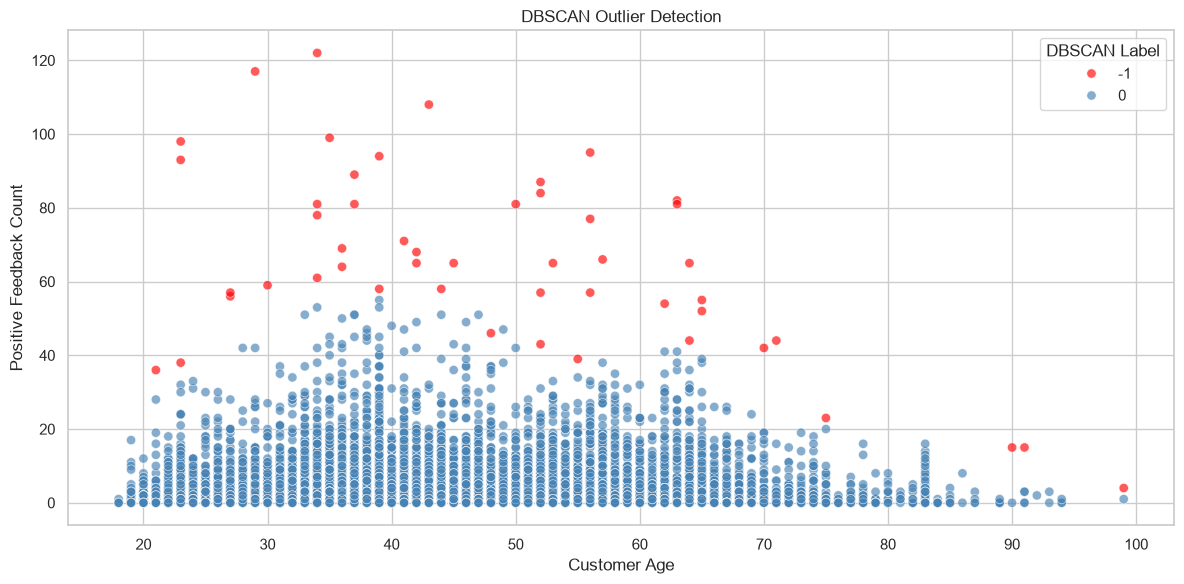

In [58]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Positive Feedback Count",
    hue="DBSCAN Label",
    palette={
        -1: "red",
        0: "steelblue"
    },
    alpha=0.65,
    s=45
)

plt.title("DBSCAN Outlier Detection")
plt.xlabel("Customer Age")
plt.ylabel("Positive Feedback Count")
plt.legend(title="DBSCAN Label")
plt.tight_layout()
plt.show()

In [59]:
method_comparison = pd.DataFrame({
    "Method": [
        "IQR",
        "Z-score",
        "DBSCAN"
    ],
    "Age Outliers": [
        age_iqr["outlier_count"],
        age_zscore["outlier_count"],
        "Combined analysis"
    ],
    "Feedback Outliers": [
        feedback_iqr["outlier_count"],
        feedback_zscore["outlier_count"],
        "Combined analysis"
    ],
    "Total DBSCAN Noise": [
        np.nan,
        np.nan,
        dbscan_outlier_count
    ]
})

method_comparison

,Method,Age Outliers,Feedback Outliers,Total DBSCAN Noise
0,IQR,109,2147,NaN
1,Z-score,99,430,NaN
2,DBSCAN,Combined analysis,Combined analysis,50.0


In [60]:
df["Age IQR Outlier"] = age_iqr["mask"]

df["Age Z-score Outlier"] = df.index.isin(
    age_zscore["outlier_indices"]
)

df["Feedback IQR Outlier"] = feedback_iqr["mask"]

df["Feedback Z-score Outlier"] = df.index.isin(
    feedback_zscore["outlier_indices"]
)

df["DBSCAN Outlier"] = (
    df["DBSCAN Label"] == -1
)

In [61]:
outlier_flag_columns = [
    "Age IQR Outlier",
    "Age Z-score Outlier",
    "Feedback IQR Outlier",
    "Feedback Z-score Outlier",
    "DBSCAN Outlier"
]

df[outlier_flag_columns].sum()

Age IQR Outlier              109
Age Z-score Outlier           99
Feedback IQR Outlier        2147
Feedback Z-score Outlier     430
DBSCAN Outlier                50
dtype: int64

In [62]:
age_overlap = pd.crosstab(
    df["Age IQR Outlier"],
    df["Age Z-score Outlier"],
    margins=True
)

age_overlap

Age Z-score Outlier,False,True,All
Age IQR Outlier,,,
False,23377,0,23377
True,10,99,109
All,23387,99,23486


In [63]:
age_both = (
    df["Age IQR Outlier"] &
    df["Age Z-score Outlier"]
).sum()

age_iqr_only = (
    df["Age IQR Outlier"] &
    ~df["Age Z-score Outlier"]
).sum()

age_zscore_only = (
    ~df["Age IQR Outlier"] &
    df["Age Z-score Outlier"]
).sum()

print("Detected by both methods:", age_both)
print("Detected only by IQR:", age_iqr_only)
print("Detected only by Z-score:", age_zscore_only)

Detected by both methods: 99
Detected only by IQR: 10
Detected only by Z-score: 0


In [64]:
feedback_overlap = pd.crosstab(
    df["Feedback IQR Outlier"],
    df["Feedback Z-score Outlier"],
    margins=True
)

feedback_overlap

Feedback Z-score Outlier,False,True,All
Feedback IQR Outlier,,,
False,21339,0,21339
True,1717,430,2147
All,23056,430,23486


In [65]:
feedback_both = (
    df["Feedback IQR Outlier"] &
    df["Feedback Z-score Outlier"]
).sum()

feedback_iqr_only = (
    df["Feedback IQR Outlier"] &
    ~df["Feedback Z-score Outlier"]
).sum()

feedback_zscore_only = (
    ~df["Feedback IQR Outlier"] &
    df["Feedback Z-score Outlier"]
).sum()

print("Detected by both methods:", feedback_both)
print("Detected only by IQR:", feedback_iqr_only)
print("Detected only by Z-score:", feedback_zscore_only)

Detected by both methods: 430
Detected only by IQR: 1717
Detected only by Z-score: 0


In [66]:
dbscan_overlap_summary = {
    "DBSCAN with Age IQR": (
        df["DBSCAN Outlier"] &
        df["Age IQR Outlier"]
    ).sum(),

    "DBSCAN with Age Z-score": (
        df["DBSCAN Outlier"] &
        df["Age Z-score Outlier"]
    ).sum(),

    "DBSCAN with Feedback IQR": (
        df["DBSCAN Outlier"] &
        df["Feedback IQR Outlier"]
    ).sum(),

    "DBSCAN with Feedback Z-score": (
        df["DBSCAN Outlier"] &
        df["Feedback Z-score Outlier"]
    ).sum()
}

for result, count in dbscan_overlap_summary.items():
    print(f"{result}: {count}")

DBSCAN with Age IQR: 3
DBSCAN with Age Z-score: 3
DBSCAN with Feedback IQR: 49
DBSCAN with Feedback Z-score: 47


In [67]:
df["Feedback Detection Count"] = (
    df["Feedback IQR Outlier"].astype(int) +
    df["Feedback Z-score Outlier"].astype(int) +
    df["DBSCAN Outlier"].astype(int)
)

df["Strong Feedback Outlier"] = (
    df["Feedback Detection Count"] >= 2
)

print(
    "Strong feedback outliers:",
    df["Strong Feedback Outlier"].sum()
)

Strong feedback outliers: 432


In [68]:
display(
    df.loc[
        df["Strong Feedback Outlier"],
        [
            "Age",
            "Rating",
            "Positive Feedback Count",
            "Feedback Detection Count",
            "Department Name",
            "Class Name"
        ]
    ]
    .sort_values(
        "Positive Feedback Count",
        ascending=False
    )
    .head(20)
)

,Age,Rating,Positive Feedback Count,Feedback Detection Count,Department Name,Class Name
7218,34,3,122,3,Dresses,Dresses
1294,29,5,117,3,Dresses,Dresses
7765,43,1,108,3,Jackets,Jackets
19094,35,5,99,3,Jackets,Outerwear
13210,23,5,98,3,Dresses,Dresses
16329,56,4,95,3,Tops,Knits
2123,39,5,94,3,Dresses,Dresses
17233,23,4,93,3,Tops,Knits
9427,37,5,89,3,Dresses,Dresses
8683,52,4,87,3,Dresses,Dresses


In [69]:
df_clean = df.copy()

print("Original rows:", len(df))
print("Copied rows:", len(df_clean))

Original rows: 23486
Copied rows: 23486


In [70]:
invalid_age_mask = ~df_clean["Age"].between(13, 100)

invalid_feedback_mask = (
    df_clean["Positive Feedback Count"] < 0
)

invalid_numerical_mask = (
    invalid_age_mask |
    invalid_feedback_mask
)

print("Invalid age records:", invalid_age_mask.sum())
print(
    "Invalid feedback records:",
    invalid_feedback_mask.sum()
)
print(
    "Total invalid numerical records:",
    invalid_numerical_mask.sum()
)

Invalid age records: 0
Invalid feedback records: 0
Total invalid numerical records: 0


In [71]:
df_clean = df_clean.loc[
    ~invalid_numerical_mask
].copy()

print("Rows after invalid-value treatment:", len(df_clean))

Rows after invalid-value treatment: 23486


In [72]:
df_clean["Positive Feedback Log"] = np.log1p(
    df_clean["Positive Feedback Count"]
)

In [73]:
display(
    df_clean[
        [
            "Positive Feedback Count",
            "Positive Feedback Log"
        ]
    ]
    .sort_values(
        "Positive Feedback Count",
        ascending=False
    )
    .head(15)
)

,Positive Feedback Count,Positive Feedback Log
7218,122,4.812184
1294,117,4.770685
7765,108,4.691348
19094,99,4.605170
13210,98,4.595120
16329,95,4.564348
2123,94,4.553877
17233,93,4.543295
9427,89,4.499810
8683,87,4.477337


In [74]:
print(
    "Missing transformed values:",
    df_clean["Positive Feedback Log"].isna().sum()
)

print(
    "Infinite transformed values:",
    np.isinf(
        df_clean["Positive Feedback Log"]
    ).sum()
)

Missing transformed values: 0
Infinite transformed values: 0


In [75]:
original_skewness = df_clean[
    "Positive Feedback Count"
].skew()

transformed_skewness = df_clean[
    "Positive Feedback Log"
].skew()

print(
    "Original feedback skewness:",
    round(original_skewness, 2)
)

print(
    "Log-transformed skewness:",
    round(transformed_skewness, 2)
)

Original feedback skewness: 6.47
Log-transformed skewness: 1.09


In [76]:
comparison_statistics = df_clean[
    [
        "Positive Feedback Count",
        "Positive Feedback Log"
    ]
].describe().T

comparison_statistics

,count,mean,std,min,25%,50%,75%,max
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.000000,3.000000,122.000000
Positive Feedback Log,23486.0,0.743792,0.888237,0.0,0.0,0.693147,1.386294,4.812184


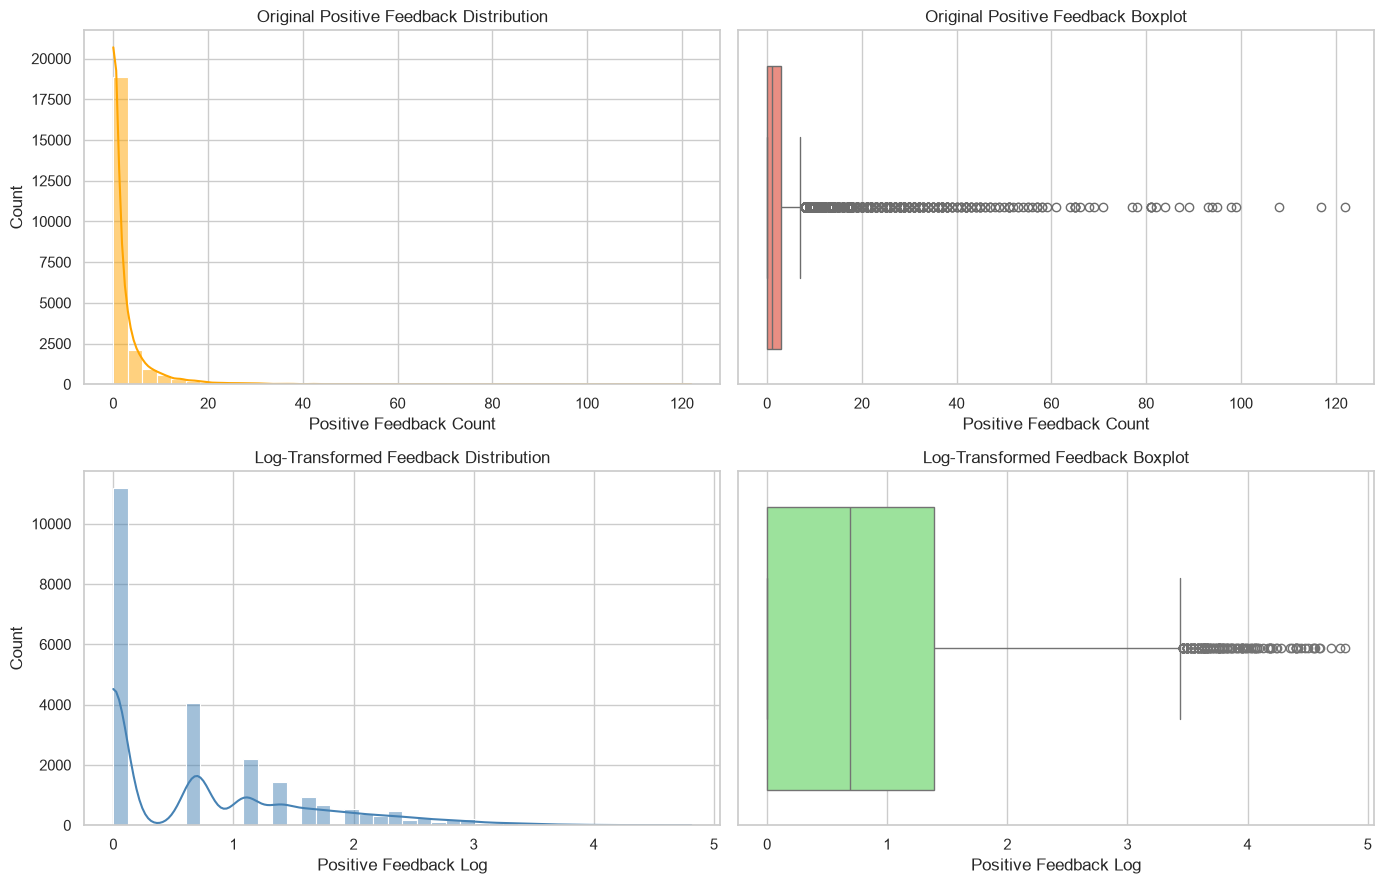

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(
    data=df_clean,
    x="Positive Feedback Count",
    bins=40,
    kde=True,
    color="orange",
    ax=axes[0, 0]
)
axes[0, 0].set_title(
    "Original Positive Feedback Distribution"
)

sns.boxplot(
    data=df_clean,
    x="Positive Feedback Count",
    color="salmon",
    ax=axes[0, 1]
)
axes[0, 1].set_title(
    "Original Positive Feedback Boxplot"
)

sns.histplot(
    data=df_clean,
    x="Positive Feedback Log",
    bins=40,
    kde=True,
    color="steelblue",
    ax=axes[1, 0]
)
axes[1, 0].set_title(
    "Log-Transformed Feedback Distribution"
)

sns.boxplot(
    data=df_clean,
    x="Positive Feedback Log",
    color="lightgreen",
    ax=axes[1, 1]
)
axes[1, 1].set_title(
    "Log-Transformed Feedback Boxplot"
)

plt.tight_layout()
plt.show()

In [78]:
age_verification = pd.DataFrame({
    "Original Age": df["Age"].describe(),
    "Cleaned Age": df_clean["Age"].describe()
})

age_verification

,Original Age,Cleaned Age
count,23486.000000,23486.000000
mean,43.198544,43.198544
std,12.279544,12.279544
min,18.000000,18.000000
25%,34.000000,34.000000
50%,41.000000,41.000000
75%,52.000000,52.000000
max,99.000000,99.000000


In [79]:
treatment_summary = pd.DataFrame({
    "Column": [
        "Age",
        "Positive Feedback Count",
        "Rating",
        "Recommended IND"
    ],
    "Detected Issue": [
        "Valid high-age statistical outliers",
        "Highly right-skewed extreme values",
        "No invalid values",
        "No invalid values"
    ],
    "Treatment": [
        "Retained",
        "Log transformed; original retained",
        "No treatment",
        "No treatment"
    ],
    "Reason": [
        "Ages 80–99 are possible customer ages",
        "High feedback can be genuine review popularity",
        "All ratings are within 1–5",
        "All values are binary 0/1"
    ]
})

treatment_summary

,Column,Detected Issue,Treatment,Reason
0,Age,Valid high-age statistical outliers,Retained,Ages 80–99 are possible customer ages
1,Positive Feedback Count,Highly right-skewed extreme values,Log transformed; original retained,High feedback can be genuine review popularity
2,Rating,No invalid values,No treatment,All ratings are within 1–5
3,Recommended IND,No invalid values,No treatment,All values are binary 0/1


In [80]:
final_columns = [
    "Clothing ID",
    "Age",
    "Title",
    "Review Text",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Positive Feedback Log",
    "Division Name",
    "Department Name",
    "Class Name"
]

final_cleaned_df = df_clean[final_columns].copy()

print("Final dataset shape:", final_cleaned_df.shape)

Final dataset shape: (23486, 11)


In [82]:
duplicate_mask = final_cleaned_df.duplicated(
    keep="first"
)

print(
    "Duplicate rows detected:",
    duplicate_mask.sum()
)

df_clean = df_clean.loc[
    ~duplicate_mask
].copy().reset_index(drop=True)

final_cleaned_df = df_clean[
    final_columns
].copy()

print(
    "Rows after duplicate removal:",
    len(final_cleaned_df)
)

print(
    "Remaining duplicates:",
    final_cleaned_df.duplicated().sum()
)

Duplicate rows detected: 21
Rows after duplicate removal: 23465
Remaining duplicates: 0


In [84]:
audit_columns = [
    "Clothing ID",
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Age IQR Outlier",
    "Age Z-score Outlier",
    "Feedback IQR Outlier",
    "Feedback Z-score Outlier",
    "DBSCAN Label",
    "DBSCAN Outlier",
    "Feedback Detection Count",
    "Strong Feedback Outlier"
]

final_columns = [
    "Clothing ID",
    "Age",
    "Title",
    "Review Text",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Positive Feedback Log",
    "Division Name",
    "Department Name",
    "Class Name"
]

final_cleaned_df = df_clean[
    final_columns
].copy()

outlier_audit_df = df_clean[
    audit_columns
].copy()

print("Final cleaned shape:", final_cleaned_df.shape)
print("Final audit shape:", outlier_audit_df.shape)

Final cleaned shape: (23465, 11)
Final audit shape: (23465, 13)


In [86]:
final_method_summary = pd.DataFrame({
    "Method": [
        "IQR – Age",
        "Z-score – Age",
        "IQR – Positive Feedback",
        "Z-score – Positive Feedback",
        "DBSCAN – Combined"
    ],

    "Detected Records": [
        int(df_clean["Age IQR Outlier"].sum()),
        int(df_clean["Age Z-score Outlier"].sum()),
        int(df_clean["Feedback IQR Outlier"].sum()),
        int(df_clean["Feedback Z-score Outlier"].sum()),
        int(df_clean["DBSCAN Outlier"].sum())
    ],

    "Final Action": [
        "Retained",
        "Retained",
        "Log transformation",
        "Log transformation",
        "Flagged and retained"
    ],

    "Reason": [
        "Extreme ages are valid customer ages",
        "Extreme ages are valid customer ages",
        "High feedback may represent genuine popularity",
        "High feedback may represent genuine popularity",
        "Noise records are unusual but not invalid"
    ]
})

display(final_method_summary)

,Method,Detected Records,Final Action,Reason
0,IQR – Age,109,Retained,Extreme ages are valid customer ages
1,Z-score – Age,99,Retained,Extreme ages are valid customer ages
2,IQR – Positive Feedback,2147,Log transformation,High feedback may represent genuine popularity
3,Z-score – Positive Feedback,430,Log transformation,High feedback may represent genuine popularity
4,DBSCAN – Combined,50,Flagged and retained,Noise records are unusual but not invalid


In [89]:
original_row_count = len(df)
final_row_count = len(final_cleaned_df)
removed_row_count = original_row_count - final_row_count

print("Original rows:", original_row_count)
print("Final rows:", final_row_count)
print("Removed rows:", removed_row_count)
print(
    "Data retained:",
    round(
        (final_row_count / original_row_count) * 100,
        2
    ),
    "%"
)

Original rows: 23486
Final rows: 23465
Removed rows: 21
Data retained: 99.91 %


In [90]:
audit_columns = [
    "Clothing ID",
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Age IQR Outlier",
    "Age Z-score Outlier",
    "Feedback IQR Outlier",
    "Feedback Z-score Outlier",
    "DBSCAN Label",
    "DBSCAN Outlier",
    "Feedback Detection Count",
    "Strong Feedback Outlier"
]

outlier_audit_df = df_clean[audit_columns].copy()

print("Audit dataset shape:", outlier_audit_df.shape)
display(outlier_audit_df.head())

Audit dataset shape: (23465, 13)


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Age IQR Outlier,Age Z-score Outlier,Feedback IQR Outlier,Feedback Z-score Outlier,DBSCAN Label,DBSCAN Outlier,Feedback Detection Count,Strong Feedback Outlier
0,767,33,4,1,0,False,False,False,False,0,False,0,False
1,1080,34,5,1,4,False,False,False,False,0,False,0,False
2,1077,60,3,0,0,False,False,False,False,0,False,0,False
3,1049,50,5,1,0,False,False,False,False,0,False,0,False
4,847,47,5,1,6,False,False,False,False,0,False,0,False


In [91]:
final_method_summary = pd.DataFrame({
    "Method": [
        "IQR – Age",
        "Z-score – Age",
        "IQR – Feedback",
        "Z-score – Feedback",
        "DBSCAN – Combined"
    ],
    "Detected Records": [
        df_clean["Age IQR Outlier"].sum(),
        df_clean["Age Z-score Outlier"].sum(),
        df_clean["Feedback IQR Outlier"].sum(),
        df_clean["Feedback Z-score Outlier"].sum(),
        df_clean["DBSCAN Outlier"].sum()
    ],
    "Action": [
        "Retained",
        "Retained",
        "Log transformation",
        "Log transformation",
        "Flagged and retained"
    ]
})

final_method_summary

,Method,Detected Records,Action
0,IQR – Age,109,Retained
1,Z-score – Age,99,Retained
2,IQR – Feedback,2147,Log transformation
3,Z-score – Feedback,430,Log transformation
4,DBSCAN – Combined,50,Flagged and retained


In [93]:
saved_df = pd.read_csv(
    "womens_clothing_outliers_cleaned.csv"
)

print("Saved file shape:", saved_df.shape)
print("Saved columns:")
print(saved_df.columns.tolist())

saved_df.head()

Saved file shape: (23465, 11)
Saved columns:
['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Positive Feedback Log', 'Division Name', 'Department Name', 'Class Name']


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Positive Feedback Log,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,0.000000,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,1.609438,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,0.000000,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,0.000000,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,1.945910,General,Tops,Blouses


In [92]:
final_cleaned_df.to_csv(
    "womens_clothing_outliers_cleaned.csv",
    index=False
)

outlier_audit_df.to_csv(
    "womens_clothing_outlier_audit.csv",
    index=False
)

final_method_summary.to_csv(
    "outlier_method_summary.csv",
    index=False
)

print("All files saved successfully.")

All files saved successfully.
